Merged data preview:
              BTC_Price  BTC_MarketCap  Stablecoin_MCap       SSR  \
date                                                                
2026-03-09  66036.15782   1.321620e+12     3.114253e+11  4.243778   
2026-03-10  68459.31537   1.369960e+12     3.124613e+11  4.384415   
2026-03-11  69883.00888   1.397520e+12     3.127843e+11  4.467999   
2026-03-12  70226.81879   1.405230e+12     3.130945e+11  4.488198   
2026-03-13  70544.42535   1.411410e+12     3.137182e+11  4.498974   

            Liquidity_Ratio  
date                         
2026-03-09         0.235639  
2026-03-10         0.228081  
2026-03-11         0.223814  
2026-03-12         0.222807  
2026-03-13         0.222273  

Summary stats:
       BTC_MarketCap  Stablecoin_MCap          SSR  Liquidity_Ratio
count   2.513000e+03     2.513000e+03  2513.000000      2513.000000
mean    8.619118e+11     1.291686e+11    14.800874         0.153360
std     6.428454e+11     8.875121e+10    21.598374         0.1044

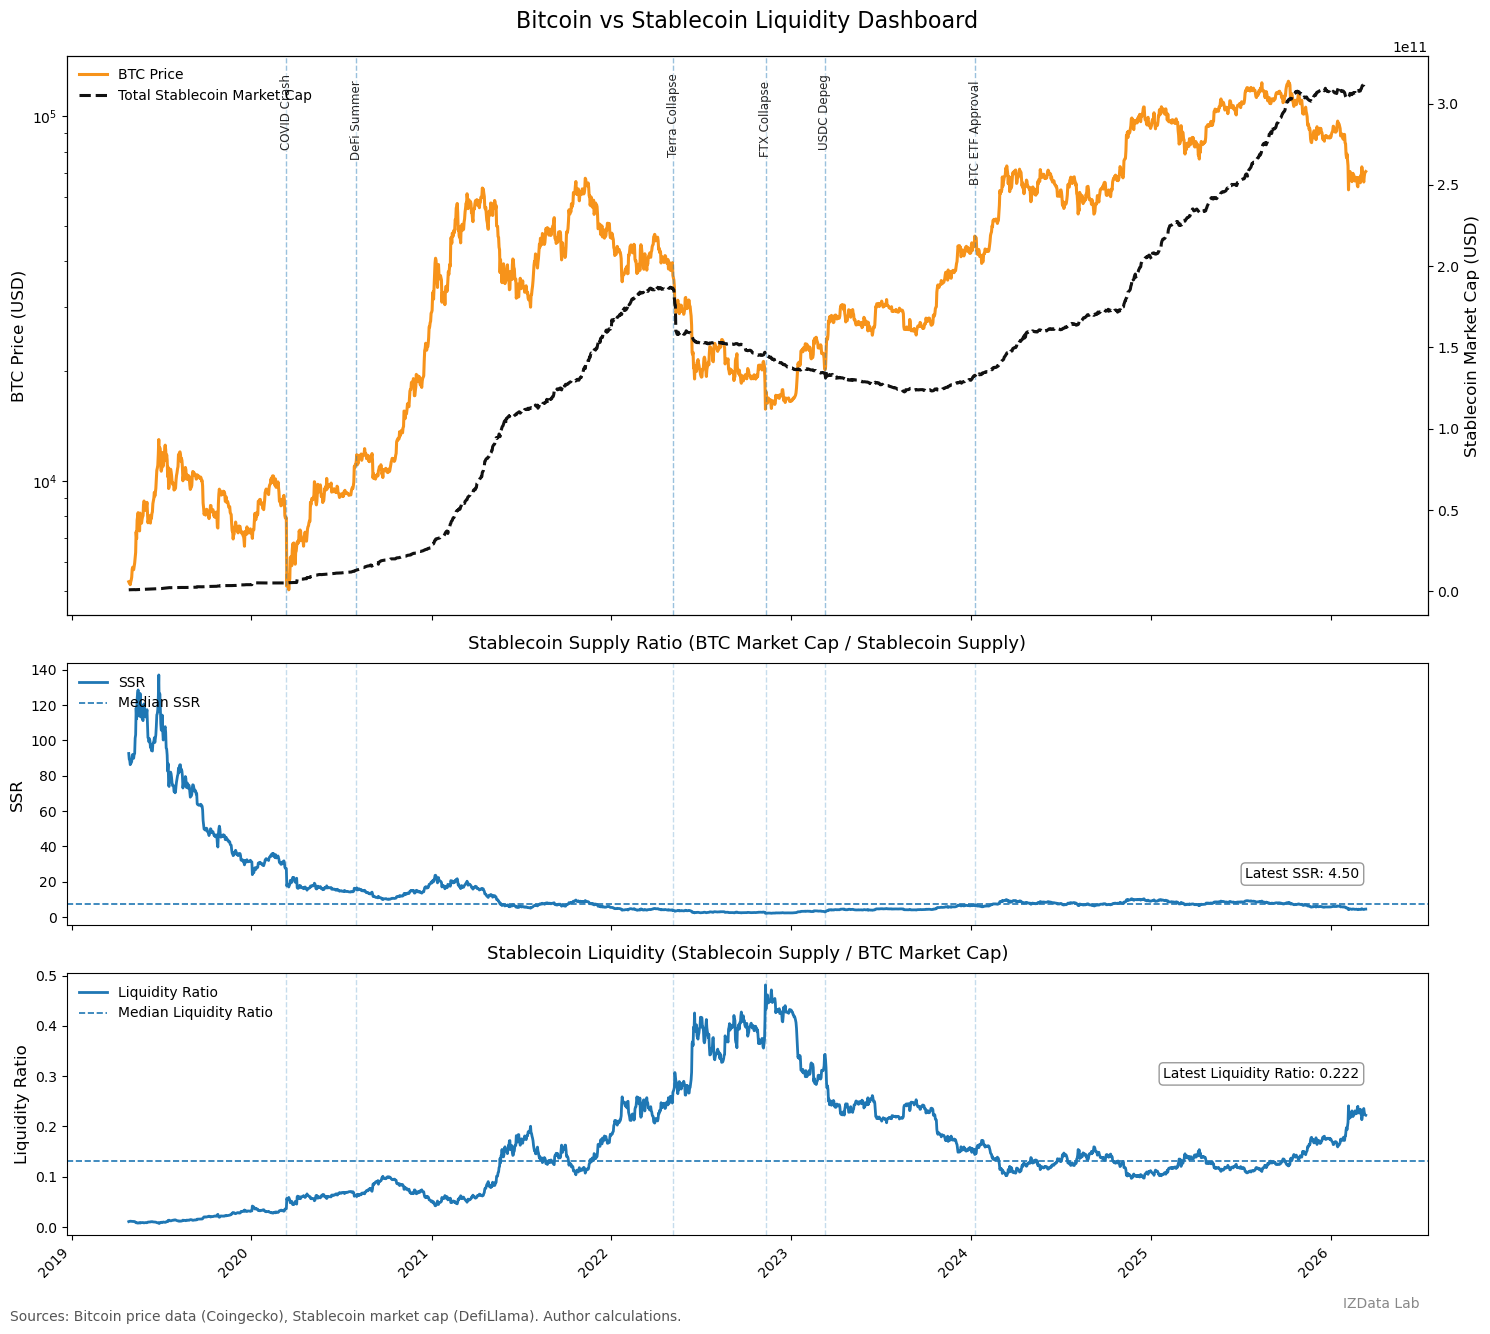

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests

# =========================================================
# 1. Load BTC price data
# =========================================================
btc = pd.read_csv("btc_usd.csv")

# Expected BTC columns:
# ['date', 'price', 'market_cap', 'total_volume']

btc["date"] = pd.to_datetime(btc["date"], utc=True, errors="coerce")
btc["date"] = btc["date"].dt.tz_localize(None)
btc["date"] = btc["date"].dt.normalize()

btc = btc.rename(columns={
    "price": "BTC_Price",
    "market_cap": "BTC_MarketCap"
})

btc = btc[["date", "BTC_Price", "BTC_MarketCap"]].copy()
btc["BTC_Price"] = pd.to_numeric(btc["BTC_Price"], errors="coerce")
btc["BTC_MarketCap"] = pd.to_numeric(btc["BTC_MarketCap"], errors="coerce")

# Keep one row per day
btc = btc.groupby("date", as_index=False).last()

# =========================================================
# 2. Download Total Stablecoin Market Cap from DefiLlama
# =========================================================
url = "https://stablecoins.llama.fi/stablecoincharts/all"
response = requests.get(url, timeout=30)
response.raise_for_status()
data = response.json()

stable = pd.DataFrame(data)

# Parse date
stable["date"] = pd.to_numeric(stable["date"], errors="coerce")
stable["date"] = pd.to_datetime(stable["date"], unit="s", utc=True, errors="coerce")
stable["date"] = stable["date"].dt.tz_localize(None)
stable["date"] = stable["date"].dt.normalize()

# Extract total stablecoin market cap
def extract_pegged_usd(x):
    if isinstance(x, dict):
        return x.get("peggedUSD")
    return x

if "totalCirculatingUSD" in stable.columns:
    stable["Stablecoin_MCap"] = stable["totalCirculatingUSD"].apply(extract_pegged_usd)
elif "totalCirculating" in stable.columns:
    stable["Stablecoin_MCap"] = stable["totalCirculating"].apply(extract_pegged_usd)
else:
    raise KeyError(
        "Could not find total stablecoin supply field in DefiLlama response. "
        f"Columns returned: {stable.columns.tolist()}"
    )

stable["Stablecoin_MCap"] = pd.to_numeric(stable["Stablecoin_MCap"], errors="coerce")
stable = stable[["date", "Stablecoin_MCap"]].copy()
stable = stable.dropna(subset=["date", "Stablecoin_MCap"])
stable = stable.groupby("date", as_index=False)["Stablecoin_MCap"].last()

# =========================================================
# 3. Merge BTC and stablecoin market cap
# =========================================================
df = pd.merge(btc, stable, on="date", how="inner").sort_values("date")
df = df.dropna(subset=["BTC_Price", "BTC_MarketCap", "Stablecoin_MCap"])

# Filter out the very early tiny-stablecoin period
df = df[df["Stablecoin_MCap"] > 1e9].copy()

df = df.set_index("date")

# =========================================================
# 4. Compute SSR and Liquidity Ratio
# =========================================================
# SSR = BTC Market Cap / Stablecoin Supply
df["SSR"] = df["BTC_MarketCap"] / df["Stablecoin_MCap"]

# Liquidity Ratio = Stablecoin Supply / BTC Market Cap
df["Liquidity_Ratio"] = df["Stablecoin_MCap"] / df["BTC_MarketCap"]

print("Merged data preview:")
print(df[["BTC_Price", "BTC_MarketCap", "Stablecoin_MCap", "SSR", "Liquidity_Ratio"]].tail())

print("\nSummary stats:")
print(df[["BTC_MarketCap", "Stablecoin_MCap", "SSR", "Liquidity_Ratio"]].describe())

print(f"\nLatest SSR: {df['SSR'].iloc[-1]:.2f}")
print(f"Latest Liquidity Ratio: {df['Liquidity_Ratio'].iloc[-1]:.3f}")

# =========================================================
# 5. Major crypto events to annotate
# =========================================================
events = {
    "COVID Crash": "2020-03-12",
    "DeFi Summer": "2020-08-01",
    "Terra Collapse": "2022-05-07",
    "FTX Collapse": "2022-11-11",
    "USDC Depeg": "2023-03-10",
    "BTC ETF Approval": "2024-01-10",
}

events = {label: pd.to_datetime(date) for label, date in events.items()}

# Keep only events that fall within the chart range
events = {
    label: date for label, date in events.items()
    if df.index.min() <= date <= df.index.max()
}

# =========================================================
# 6. Plot 3-panel dashboard
# =========================================================
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(15, 13),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.5, 1.5]}
)

# -------------------------
# Panel 1: BTC Price + Stablecoin Market Cap
# -------------------------
ax1.plot(df.index, df["BTC_Price"], linewidth=2.2, color="#f7931a", label="BTC Price")
ax1.set_ylabel("BTC Price (USD)", fontsize=12)
ax1.set_yscale("log")


ax1b = ax1.twinx()
ax1b.plot(
    df.index,
    df["Stablecoin_MCap"],
    linewidth=2.2,
    linestyle="--",
    color="#111111",
    label="Total Stablecoin Market Cap"
)
ax1b.set_ylabel("Stablecoin Market Cap (USD)", fontsize=12)

ax1.set_title(
    "Bitcoin vs Stablecoin Liquidity Dashboard",
    fontsize=16,
    pad=20
)

# Combined legend for panel 1
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

# Add vertical event markers to all panels
for label, date in events.items():
    ax1.axvline(date, linestyle="--", linewidth=1.0, alpha=0.45)
    ax2.axvline(date, linestyle="--", linewidth=1.0, alpha=0.25)
    ax3.axvline(date, linestyle="--", linewidth=1.0, alpha=0.25)

# Add event labels on Panel 1 only
y_top = ax1.get_ylim()[1]
for i, (label, date) in enumerate(events.items()):
    # stagger labels slightly so they do not all sit at exactly the same height
    y_pos = y_top / (1.12 + 0.05 * (i % 2))
    ax1.text(
        date,
        y_pos,
        label,
        rotation=90,
        fontsize=8.5,
        alpha=0.85,
        ha="center",
        va="top",
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.55, edgecolor="none")
    )

# -------------------------
# Panel 2: SSR
# -------------------------
ax2.plot(df.index, df["SSR"], linewidth=2.0, label="SSR")
ax2.axhline(df["SSR"].median(), linewidth=1.2, linestyle="--", label="Median SSR")
ax2.set_ylabel("SSR", fontsize=12)
ax2.set_title("Stablecoin Supply Ratio (BTC Market Cap / Stablecoin Supply)", fontsize=13, pad=10)
ax2.legend(loc="upper left", frameon=False)

ax2.text(
    0.95, 0.18,
    f"Latest SSR: {df['SSR'].iloc[-1]:.2f}",
    transform=ax2.transAxes,
    fontsize=10,
    ha="right",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="gray")
)

# -------------------------
# Panel 3: Liquidity Ratio
# -------------------------
ax3.plot(df.index, df["Liquidity_Ratio"], linewidth=2.0, label="Liquidity Ratio")
ax3.axhline(
    df["Liquidity_Ratio"].median(),
    linewidth=1.2,
    linestyle="--",
    label="Median Liquidity Ratio"
)
ax3.set_ylabel("Liquidity Ratio", fontsize=12)
ax3.set_title("Stablecoin Liquidity (Stablecoin Supply / BTC Market Cap)", fontsize=13, pad=10)
ax3.legend(loc="upper left", frameon=False)

ax3.text(
    0.95, 0.60,
    f"Latest Liquidity Ratio: {df['Liquidity_Ratio'].iloc[-1]:.3f}",
    transform=ax3.transAxes,
    fontsize=10,
    ha="right",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="gray")
)

# X-axis formatting
ax3.xaxis.set_major_locator(mdates.YearLocator(1))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right")

fig.text(
    0.01,
    -0.02,
    "Sources: Bitcoin price data (Coingecko), Stablecoin market cap (DefiLlama). Author calculations.",
    ha="left",
    fontsize=10,
    color="#555555"
)


fig.text(
    0.95, -0.01,
    "IZData Lab",
    fontsize=10,
    color="#888888",
    ha="right"
)

plt.tight_layout()
plt.savefig("bitcoin_vs_stablecoin_liquidity.png", dpi=300, bbox_inches="tight")
plt.show()
